# Analysis of the dataset

### Module imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

Data import

In [2]:
data_path = Path("../data/sportoclanky.csv.gz")

In [3]:
df = pd.read_csv(data_path)

In [4]:
df.head(10)

,category,rss_title,rss_perex
0,biatlon,"Krčmář dojel v hromadném závodě devátý, díky s...",Závod s hromadným startem v německém Oberhofu ...
1,biatlon,Česká vlajka byla v Pokljuce vidět i ve štafet...,Galerie
2,biatlon,Živě: Stíhací závod biatlonistek v Ruhpoldingu,"15. 1., 14:45"
3,fotbal,Bakoš dostal herdu do nosu a v zápase plném ka...,Slovenský útočník Marek Bakoš zařídil Plzni gó...
4,fotbal,"My moc chtěli a Plzeň moc nechtěla, zní z Ďolí...",Český fotbal hledá viníka skandálu odloženého ...
5,fotbal,Novou sezonu otevře zápas Brna s nováčkem Ostr...,Podívejte se na program prvního kola nové fotb...
6,fotbal,S Radou už Sparta moc nepočítá. Kotalík hledá ...,Pokud se ještě fotbalisté Sparty nevyhrabou na...
7,fotbal,Viktoria Žižkov musí Praze 3 zaplatit 800 tisí...,"Rozhodl o tom pražský městský soud, který potv..."
8,fotbal,Živě: Slavia získala na úvod jarní části tři b...,"18. 2., 16:45"
9,fotbal,Chvílemi jsme se báli o nohy. Ale dva góly jso...,Dvěma góly a přihrávkou nasměroval Antonín Bar...


### Dataset size

Total number of rows in the dataset

In [5]:
df_rows_count = df.shape[0]
df_rows_count

111218

### Duplicates

Fully identical rows

In [6]:
full_duplicates = sum(df.duplicated())
print(f"There is exactly {full_duplicates} of fully duplicated rows in the dataset - {full_duplicates/df_rows_count*100:.2f}% of all rows")

There is exactly 7185 of fully duplicated rows in the dataset - 6.46% of all rows


Rows where there are duplicates for title + perex

In [7]:
text_duplicates = df.duplicated(subset=["rss_title", "rss_perex"]).sum()
print(f"Duplicate texts (title+perex): {text_duplicates} ({text_duplicates/df_rows_count*100:.2f}%)")

Duplicate texts (title+perex): 7199 (6.47%)


Rows where only the titles are duplicate

In [8]:
title_duplicates = df.duplicated(subset=["rss_title"]).sum()
print(f"Duplicate titles: {title_duplicates} ({title_duplicates/df_rows_count*100:.2f}%)")

Duplicate titles: 11694 (10.51%)


Rows where same text (title + perex) are mapped to different labels over more rows

In [9]:
multi_category_duplicates = df.groupby(["rss_title", "rss_perex"])["category"].nunique()

In [10]:
conflicting = multi_category_duplicates[multi_category_duplicates > 1]
print(f"Texts assigned to > 1 category: {len(conflicting)}")

Texts assigned to > 1 category: 13


### Missing values

Function to catch both NaN as well as empty string values

In [11]:
def is_blank(col) -> bool:
    filled = col.fillna("")
    trimmed = filled.str.strip()
    return trimmed == ""

Apply to the dataframe

In [12]:
blank = pd.DataFrame({
    "category_blank": is_blank(df["category"]),
    "title_blank": is_blank(df["rss_title"]),
    "perex_blank": is_blank(df["rss_perex"]),
})

In [13]:
blank.head()

,category_blank,title_blank,perex_blank
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


In [14]:
print(blank.sum())

category_blank    0
title_blank       0
perex_blank       0
dtype: int64


### Text lengths

Get the number of chars and words per row for both the title as well as perex

In [15]:
lengths = pd.DataFrame({
    "title_chars": df["rss_title"].str.len(),
    "perex_chars": df["rss_perex"].str.len(),
    "title_words": df["rss_title"].str.split().str.len(),
    "perex_words": df["rss_perex"].str.split().str.len(),
})

Get the counts of chars and words for the combined 

In [16]:
combined = df["rss_title"] + " " + df["rss_perex"]
lengths["combined_chars"] = combined.str.len()
lengths["combined_words"] = combined.str.split().str.len()

Count, average mean, percentiles for each content value of articles

In [17]:
display(lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))

,title_chars,perex_chars,title_words,perex_words,combined_chars,combined_words
count,111218.0,111218.0,111218.0,111218.0,111218.0,111218.0
mean,64.7,305.5,10.3,47.4,371.2,57.6
std,16.6,157.0,2.9,24.8,158.6,25.1
min,3.0,3.0,1.0,1.0,9.0,2.0
50%,66.0,304.0,10.0,47.0,367.0,57.0
90%,82.0,498.0,13.0,78.0,567.0,89.0
95%,90.0,570.0,15.0,89.0,640.0,100.0
99%,100.0,711.0,17.0,112.0,785.0,124.0
max,188.0,2666.0,31.0,434.0,2751.0,447.0


Histograms of title, perex and title+perex (combination) word counts

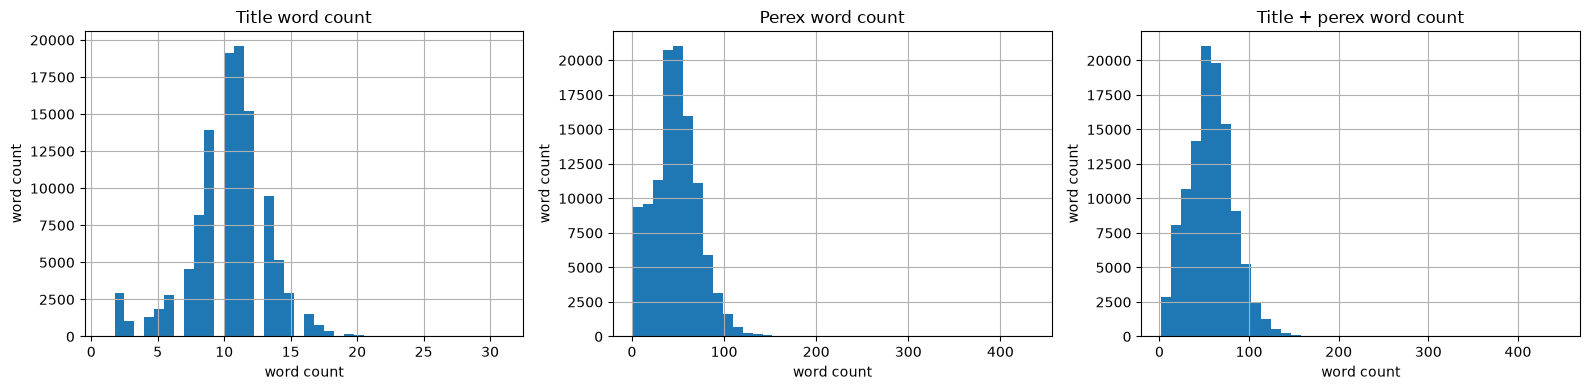

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lengths["title_words"].hist(bins=40, ax=axes[0])
axes[0].set_title("Title word count")

lengths["perex_words"].hist(bins=40, ax=axes[1])
axes[1].set_title("Perex word count")

lengths["combined_words"].hist(bins=40, ax=axes[2])
axes[2].set_title("Title + perex word count")

for ax in axes:
    ax.set_xlabel("word count")
    ax.set_ylabel("word count")

plt.tight_layout()
plt.show()

Histograms of title, perex and title+perex (combination) character counts

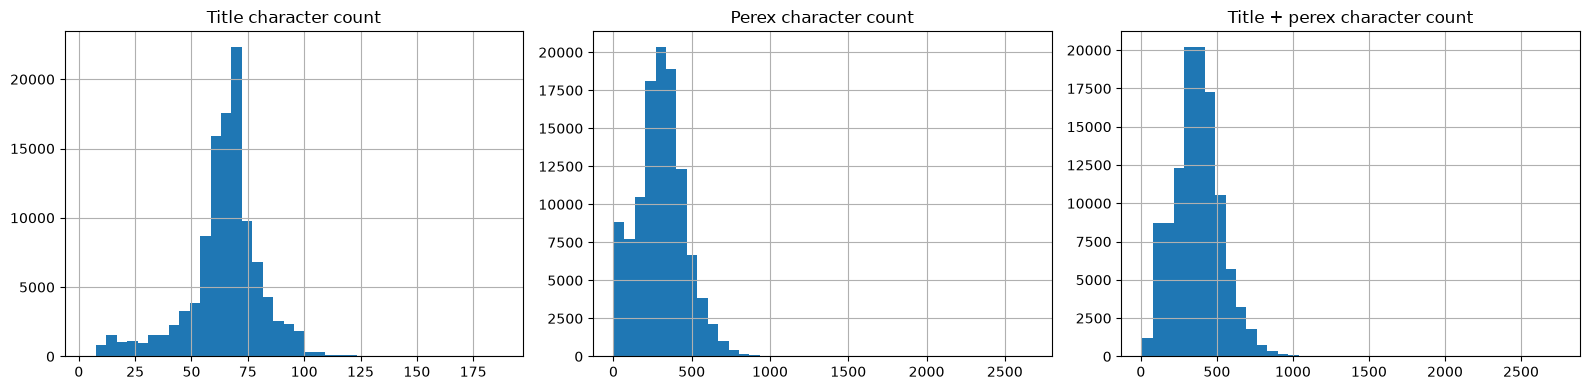

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lengths["title_chars"].hist(bins=40, ax=axes[0])
axes[0].set_title("Title character count")

lengths["perex_chars"].hist(bins=40, ax=axes[1])
axes[1].set_title("Perex character count")

lengths["combined_chars"].hist(bins=40, ax=axes[2])
axes[2].set_title("Title + perex character count")

ax.set_ylabel("number of articles")

plt.tight_layout()
plt.show()

### Class distribution

Total counts of rows per category and the percentage to total count

In [20]:
counts = df["category"].value_counts()                
percentages = (counts / len(df) * 100).round(2) 

In [21]:
counts

category
fotbal            45891
hokej             28775
tenis             11437
formule1           5733
moto               4813
atletika           2552
basketbal          2492
cyklistika         2048
biatlon            1526
olympijske_hry     1322
lyze_snowboard      957
volejbal            838
hazena              666
vodni_sporty        601
florbal             527
golf                455
box                 149
baseball            143
krasobrusleni        77
rychlobrusleni       65
dostihy              56
rugby                46
futsal               43
hokejbal              6
Name: count, dtype: int64

In [22]:
percentages

category
fotbal            41.26
hokej             25.87
tenis             10.28
formule1           5.15
moto               4.33
atletika           2.29
basketbal          2.24
cyklistika         1.84
biatlon            1.37
olympijske_hry     1.19
lyze_snowboard     0.86
volejbal           0.75
hazena             0.60
vodni_sporty       0.54
florbal            0.47
golf               0.41
box                0.13
baseball           0.13
krasobrusleni      0.07
rychlobrusleni     0.06
dostihy            0.05
rugby              0.04
futsal             0.04
hokejbal           0.01
Name: count, dtype: float64

Class distribution graph

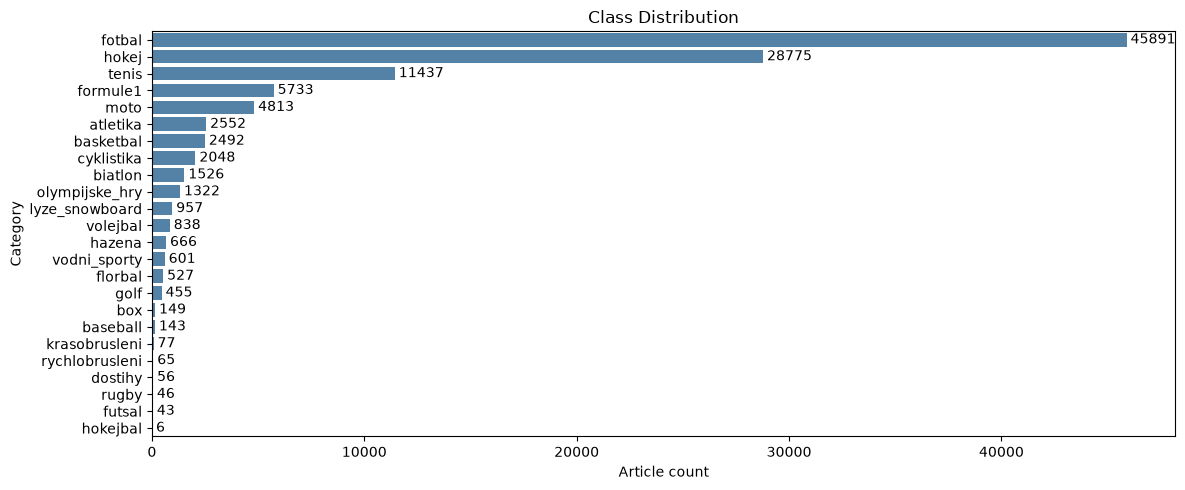

In [23]:
plt.figure(figsize=(12, 5))
sns.barplot(x=counts.values, y=counts.index, color="steelblue")
plt.xlabel("Article count")
plt.ylabel("Category")
plt.title("Class Distribution")
for i, v in enumerate(counts.values):
    plt.text(v, i, f" {v}", va="center")   
plt.tight_layout()
plt.show()

Value examples

In [24]:
for category, group in df.groupby("category"):
    print(f"\n===== {category} =====")
    for _, row in group.sample(3, random_state=42).iterrows():
        print(f"  TITLE: {row['rss_title']}")
        print(f"  PEREX: {row['rss_perex']}\n")


===== atletika =====
  TITLE: Anna Čičerovová
  PEREX: Moskva - Ruská výškařka Anna Čičerovová patří mezi sportovce, kterým po novém otestování vzorků z olympijských her v Pekingu 2008 hrozí trest za doping. Podle trenéra atletky, která v Pekingu získala bronz a o čtyři roky později v Londýně triumfovala, přišlo Čičerovové upozornění na pozitivní výsledek zpětné zkoušky.

  TITLE: Česká holka z večerky. Běhala v parku, na MS ji čeká souboj s hvězdami
  PEREX: PŘÍMO Z LONDÝNA | Večerka Srdíčko v ulici Sokola Tůmy v centru Českého Těšína se musí pár dní obejít bez šikovné pomocnice. Simona Vrzalová vyrazila do světa a večer se na London Stadium postaví na dráhu v rozběhu na 1500 metrů na mistrovství světa vedle Caster Semenyaové nebo Genzebe Dibabaové.

  TITLE: Štafeta mužů na 4x400 m zaběhla český rekord a drží šanci na Rio
  PEREX: Štafeta mužů na 4x400 metrů ve složení Jan Tesař, Pavel Maslák, Michal Desenský a Patrik Šorm v sobotu vybojovala na mistrovství Evropy v Amsterdamu přímý